In [1]:
# Install essentials
!pip install tensorflow matplotlib seaborn opencv-python-headless streamlit

# Imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
!unzip archive.zip

Streaming output truncated to the last 5000 lines.
  inflating: Positive/15001_1.jpg    
  inflating: Positive/15002_1.jpg    
  inflating: Positive/15003_1.jpg    
  inflating: Positive/15004_1.jpg    
  inflating: Positive/15005_1.jpg    
  inflating: Positive/15006_1.jpg    
  inflating: Positive/15007_1.jpg    
  inflating: Positive/15008_1.jpg    
  inflating: Positive/15009_1.jpg    
  inflating: Positive/15010_1.jpg    
  inflating: Positive/15011_1.jpg    
  inflating: Positive/15012_1.jpg    
  inflating: Positive/15013_1.jpg    
  inflating: Positive/15014_1.jpg    
  inflating: Positive/15015_1.jpg    
  inflating: Positive/15016_1.jpg    
  inflating: Positive/15017_1.jpg    
  inflating: Positive/15018_1.jpg    
  inflating: Positive/15019_1.jpg    
  inflating: Positive/15020_1.jpg    
  inflating: Positive/15021_1.jpg    
  inflating: Positive/15022_1.jpg    
  inflating: Positive/15023_1.jpg    
  inflating: Positive/15024_1.jpg    
  inflating: Positive/15025_1.jpg    

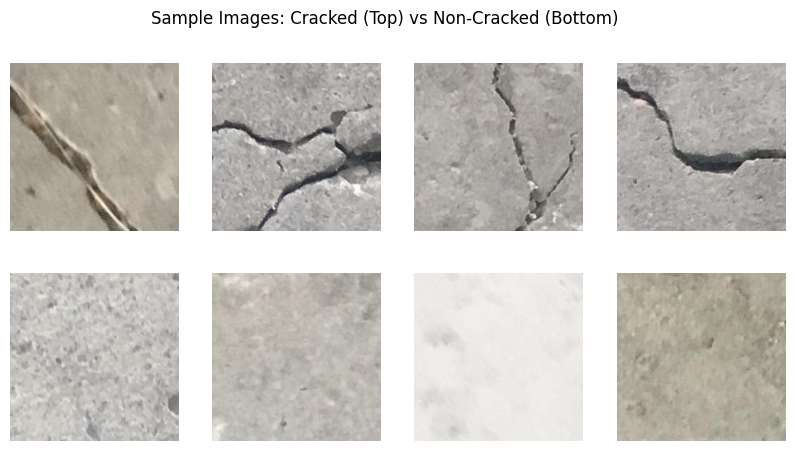

In [3]:
base_path = '/content/Surface_Crack_Detection/'

# Preview sample images
import random
from PIL import Image

cracked = os.listdir(base_path + 'Positive')[:4]
non_cracked = os.listdir(base_path + 'Negative')[:4]

fig, axes = plt.subplots(2,4, figsize=(10,5))
for i,img in enumerate(cracked+non_cracked):
    im = Image.open(base_path + ('Positive/' if i<4 else 'Negative/') + img)
    axes[i//4, i%4].imshow(im)
    axes[i//4, i%4].axis('off')
plt.suptitle("Sample Images: Cracked (Top) vs Non-Cracked (Bottom)")
plt.show()

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    brightness_range=[0.8,1.2],
    shear_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    base_path, target_size=(128,128),
    batch_size=32, class_mode='binary', subset='training'
)

val_gen = train_datagen.flow_from_directory(
    base_path, target_size=(128,128),
    batch_size=32, class_mode='binary', subset='validation'
)

Found 32000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.


In [5]:
import os
from PIL import Image

print("🔍 Checking dataset configuration...")

# 1. Verify class labels
print("Class Indices:", train_gen.class_indices)

# 2. Check number of samples
print(f"Train samples: {train_gen.samples}, Validation samples: {val_gen.samples}")

# 3. Peek at batch labels
x_batch, y_batch = next(train_gen)
print("Sample labels in batch:", y_batch[:20])

# 4. Check if all images are RGB and same size
sample_path = train_gen.filepaths[0]
img = Image.open(sample_path)
print("Sample image mode:", img.mode)
print("Sample image size:", img.size)

# 5. Check for duplicate files between train/val
train_files = set(os.path.basename(p) for p in train_gen.filepaths)
val_files = set(os.path.basename(p) for p in val_gen.filepaths)
overlap = train_files.intersection(val_files)
print(f"Overlapping images between train/val: {len(overlap)}")

if len(overlap) > 0:
    print("⚠️ Duplicate images detected between training and validation sets!")
else:
    print("✅ No duplicate images between train/validation.")

print("✅ Dataset verification complete.")

🔍 Checking dataset configuration...
Class Indices: {'Negative': 0, 'Positive': 1}
Train samples: 32000, Validation samples: 8000
Sample labels in batch: [0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0.]
Sample image mode: RGB
Sample image size: (227, 227)
Overlapping images between train/val: 0
✅ No duplicate images between train/validation.
✅ Dataset verification complete.


In [6]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,833 (28.20 MB)

 Trainable params: 7,392,641 (28.20 MB)

 Non-trainable params: 192 (768.00 B)

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('/content/best_cnn_model.h5', save_best_only=True)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9121 - loss: 0.7155

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 219s 212ms/step - accuracy: 0.9121 - loss: 0.7152 - val_accuracy: 0.9911 - val_loss: 0.2906
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 205s 205ms/step - accuracy: 0.9809 - loss: 0.3255 - val_accuracy: 0.9681 - val_loss: 0.3580
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9849 - loss: 0.2634

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 205s 205ms/step - accuracy: 0.9849 - loss: 0.2633 - val_accuracy: 0.9937 - val_loss: 0.2122
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9863 - loss: 0.2274

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 206s 206ms/step - accuracy: 0.9863 - loss: 0.2274 - val_accuracy: 0.9911 - val_loss: 0.1814
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9869 - loss: 0.1983

...

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 202s 202ms/step - accuracy: 0.9907 - loss: 0.1096 - val_accuracy: 0.9952 - val_loss: 0.0926
Epoch 12/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9926 - loss: 0.0994

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 200s 200ms/step - accuracy: 0.9926 - loss: 0.0994 - val_accuracy: 0.9944 - val_loss: 0.0885
Epoch 13/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 202s 202ms/step - accuracy: 0.9914 - loss: 0.1017 - val_accuracy: 0.9761 - val_loss: 0.1521
Epoch 14/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9915 - loss: 0.1010

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 203s 203ms/step - accuracy: 0.9915 - loss: 0.1010 - val_accuracy: 0.9951 - val_loss: 0.0819
Epoch 15/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 203s 203ms/step - accuracy: 0.9921 - loss: 0.0897 - val_accuracy: 0.9935 - val_loss: 0.0835
Epoch 16/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 203s 203ms/step - accuracy: 0.9922 - loss: 0.0913 - val_accuracy: 0.9843 - val_loss: 0.1176
Epoch 17/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9921 - loss: 0.0922

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 205s 205ms/step - accuracy: 0.9921 - loss: 0.0922 - val_accuracy: 0.9942 - val_loss: 0.0752
Epoch 18/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 204s 204ms/step - accuracy: 0.9926 - loss: 0.0834 - val_accuracy: 0.9940 - val_loss: 0.0755
Epoch 19/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9929 - loss: 0.0813

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 204s 204ms/step - accuracy: 0.9929 - loss: 0.0813 - val_accuracy: 0.9960 - val_loss: 0.0719
Epoch 20/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 205s 205ms/step - accuracy: 0.9912 - loss: 0.0871 - val_accuracy: 0.5013 - val_loss: 22.1082


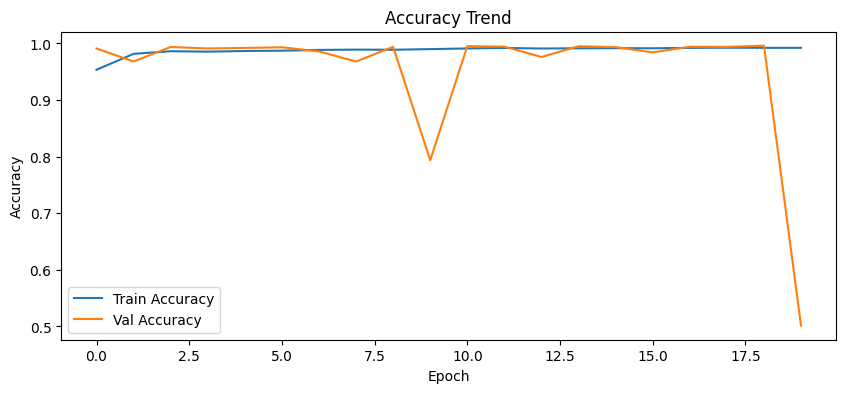

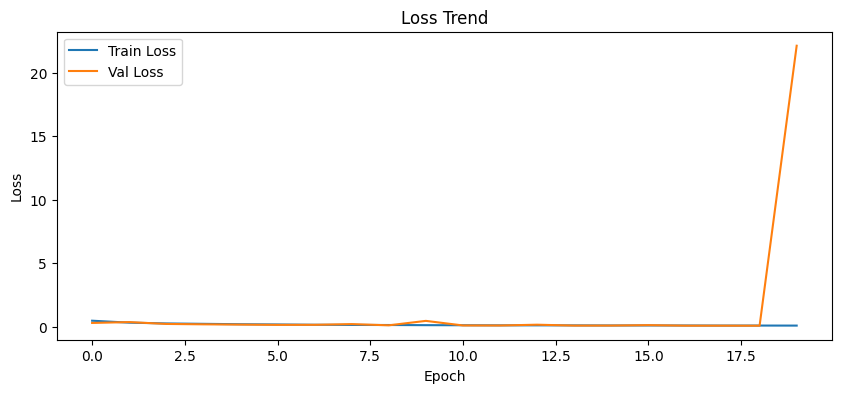

In [8]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Trend')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Trend')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

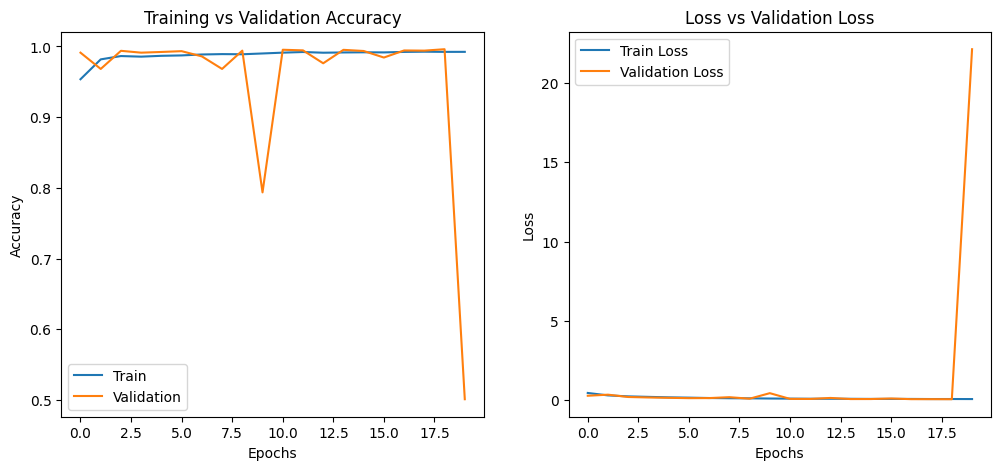

In [9]:
# Accuracy & Loss Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Training vs Validation Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss vs Validation Loss'); plt.legend()
plt.show()

In [11]:
model.save('cnn_crack_model_final.h5')
print("✅ Final model saved successfully!")

✅ Final model saved successfully!


In [12]:
from tensorflow.keras.models import load_model

# Load your trained model
model = load_model("cnn_crack_model_final.h5")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,835 (28.20 MB)

 Trainable params: 7,392,641 (28.20 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 2 (12.00 B)

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = "/content/Surface_Crack_Detection"  # change this to your dataset path

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 8000 images belonging to 2 classes.


In [14]:
loss, accuracy = model.evaluate(val_gen)
print(f"✅ Validation Accuracy: {accuracy*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9963 - loss: 0.0717
✅ Validation Accuracy: 99.71%
Validation Loss: 0.0661


250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      4000
    Positive       1.00      1.00      1.00      4000

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



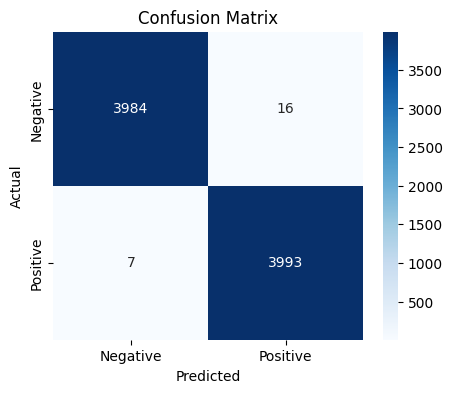

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predict
y_pred = model.predict(val_gen)
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)
y_true = val_gen.classes

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=list(val_gen.class_indices.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(val_gen.class_indices.keys()), yticklabels=list(val_gen.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

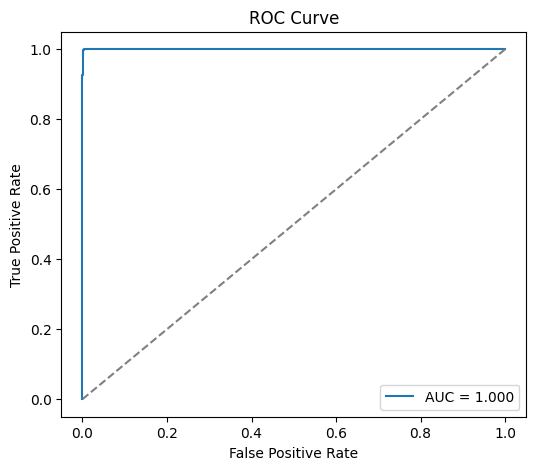

In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step


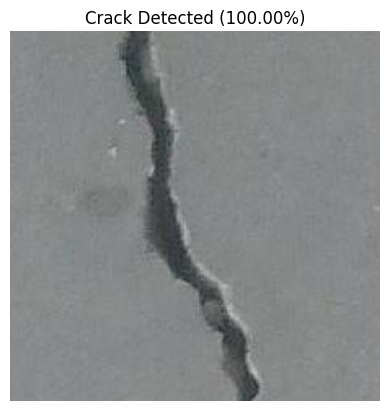

In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

test_img_path = "/content/Surface_Crack_Detection/Positive/00001.jpg"  # change path
img = image.load_img(test_img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]
label = "Crack Detected" if prediction > 0.5 else "No Crack Detected"
confidence = prediction if prediction > 0.5 else 1 - prediction

plt.imshow(image.load_img(test_img_path))
plt.axis("off")
plt.title(f"{label} ({confidence*100:.2f}%)")
plt.show()

In [18]:
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
import numpy as np, cv2, matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 1️⃣ Define model functionally — inputs are explicit, so always defined
inputs = Input(shape=(128,128,3))
x = Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.001))(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2,2)(x)

x = Flatten()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.6)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.load_weights("/content/cnn_crack_model_final.h5")

print("✅ Functional model ready!")
print("Input:", model.input)
print("Output:", model.output)

✅ Functional model ready!
Input: <KerasTensor shape=(None, 128, 128, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_66>
Output: <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_76>


In [19]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

/tmp/ipython-input-2172673040.py:8: RuntimeWarning: invalid value encountered in cast
  heatmap = np.uint8(255 * heatmap)


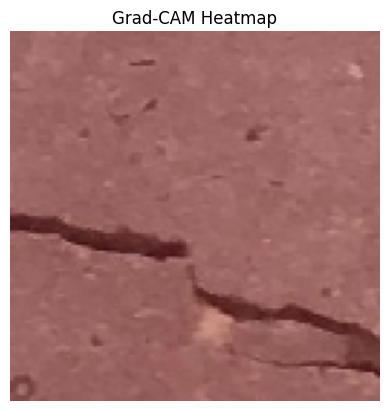

In [21]:
img_path = "/content/Surface_Crack_Detection/Positive/19810.jpg"
img = image.load_img(img_path, target_size=(128,128))
img_array = np.expand_dims(image.img_to_array(img)/255.0, axis=0)

heatmap = make_gradcam_heatmap(img_array, model, "conv2d_3")

heatmap = cv2.resize(heatmap, (128,128))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
overlay = cv2.addWeighted(np.uint8(image.img_to_array(img)), 0.6, heatmap, 0.4, 0)

plt.imshow(overlay.astype("uint8"))
plt.axis("off")
plt.title("Grad-CAM Heatmap")
plt.show()

In [22]:
results = {
    "Validation Accuracy": accuracy,
    "Validation Loss": loss,
    "AUC": roc_auc,
}
import json
with open("model_evaluation.json", "w") as f:
    json.dump(results, f, indent=4)
print(json.dumps(results, indent=4))

{
    "Validation Accuracy": 0.9971250295639038,
    "Validation Loss": 0.06608262658119202,
    "AUC": 0.9999450625
}
